In [2]:
#Como siempre cargamos librerías que son interesantes/necesarias 
import numpy as np 
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch import nn,optim

In [3]:
#Vemos si tenemos una GPU disponible, si no, usamos la CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
transformacion = transforms.Compose([transforms.ToTensor(),
                                      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) 
#Esta normalización es muy típica ya que deja todo en el rango [-1,1]

In [5]:
cifar_train = datasets.CIFAR10(root='data',train=True,download=True,transform=transformacion)
cifar_test = datasets.CIFAR10(root='data',train=False,download=True,transform=transformacion)

c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
cifar_train[0][0].shape 
#Esta es otra manera a la de iter para sacar los items de un dataloader

torch.Size([3, 32, 32])

In [7]:
train = torch.utils.data.DataLoader(cifar_train,batch_size=32,shuffle=True,num_workers=0)
test = torch.utils.data.DataLoader(cifar_test,batch_size=32,shuffle=True,num_workers=0)

# Aquí implemento la estructura encoder-decoder

In [10]:
class AE(nn.Module):
    def __init__(self):
        super(AE,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(3*32*32, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3*32*32),
            nn.Tanh() #Para que la salida esté entre -1 y 1, igual que la entrada tras la normalización
        )
    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Entrenando en: cpu
Época [1/15], Loss: 0.0927
Época [2/15], Loss: 0.0705
Época [3/15], Loss: 0.0660
Época [4/15], Loss: 0.0629
Época [5/15], Loss: 0.0599
Época [6/15], Loss: 0.0580
Época [7/15], Loss: 0.0569
Época [8/15], Loss: 0.0563
Época [9/15], Loss: 0.0553
Época [10/15], Loss: 0.0544
Época [11/15], Loss: 0.0542
Época [12/15], Loss: 0.0540
Época [13/15], Loss: 0.0539
Época [14/15], Loss: 0.0535
Época [15/15], Loss: 0.0530


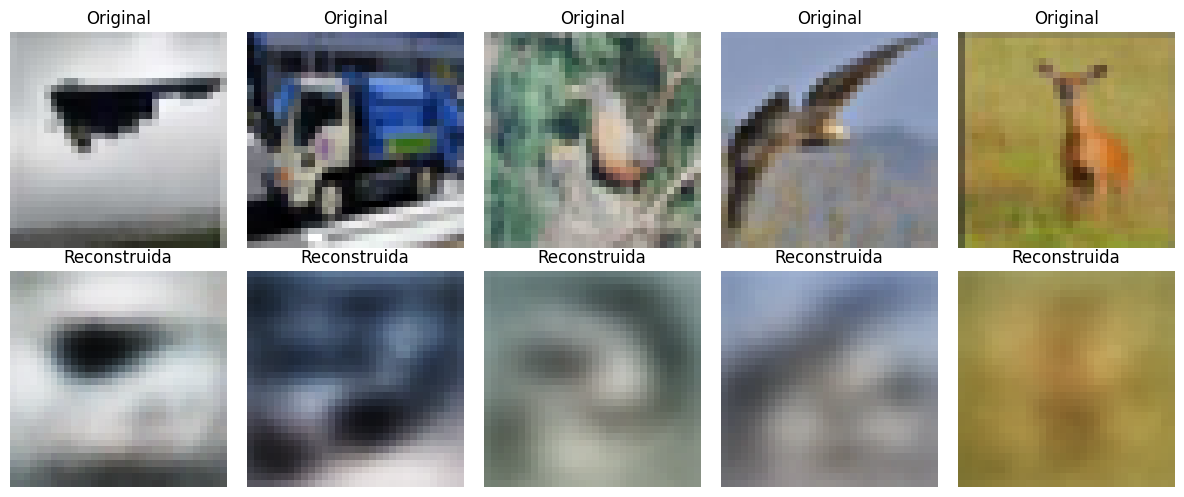

In [13]:
model = AE().to(device)
optimizador = optim.Adam(model.parameters(), lr=0.001)
criterio = nn.MSELoss()
epochs = 15

print(f"Entrenando en: {device}")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for img, _ in train:
        img = img.to(device)
        img_flat = img.view(img.size(0), -1) 

        output = model(img_flat)
        loss = criterio(output, img_flat)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        train_loss += loss.item()
    print(f"Época [{epoch+1}/{epochs}], Loss: {train_loss/len(train):.4f}")

model.eval() 
with torch.no_grad():
    dataiter = iter(test)
    imagenes, _ = next(dataiter)
    
    img_test = imagenes.to(device)
    img_test_flat = img_test.view(img_test.size(0), -1)
    
    reconstruidas_flat = model(img_test_flat)
    reconstruidas = reconstruidas_flat.view(-1, 3, 32, 32).cpu()

plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    img_original = imagenes[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img_original)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    img_rec = reconstruidas[i].permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img_rec)
    plt.title("Reconstruida")
    plt.axis('off')

plt.tight_layout()
plt.show()